# xG shot maps: two World Cup finals

Same function, two matches: `get_xg_shot_map(match)`.

Marker **size** is StatsBomb xG. **Gold edge** is a goal. Penalty shootouts are dropped (period 5) so 2022 is the 3–3 match, not the 4–2 lottery.

- 2018 — France vs Croatia
- 2022 — Argentina vs France

In [1]:
from pathlib import Path

import pandas as pd

from football_data import (
    get_xg_shot_map,
    match_shot_summary,
    world_cup_2018_final,
    world_cup_2022_final,
)

OUTPUTS = Path("outputs")
if not OUTPUTS.exists():
    OUTPUTS = Path("..") / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

wc18 = world_cup_2018_final()
wc22 = world_cup_2022_final()
wc18, wc22

(MatchInfo(match_id=8658, home_team='France', away_team='Croatia', home_score=4, away_score=2, match_date='2018-07-15', competition_stage='Final'),
 MatchInfo(match_id=3869685, home_team='Argentina', away_team='France', home_score=3, away_score=3, match_date='2022-12-18', competition_stage='Final'))

## Chance quality vs goals

`match_shot_summary` is the JSON-friendly table a future API would return.

In [2]:
summary = pd.concat(
    [match_shot_summary(wc18), match_shot_summary(wc22)],
    ignore_index=True,
)
summary.round({"xg": 2})

,match,match_id,team,shots,goals,xg
0,France vs Croatia,8658,Croatia,15,2,1.48
1,France vs Croatia,8658,France,8,3,1.10
2,Argentina vs France,3869685,Argentina,20,3,2.76
3,Argentina vs France,3869685,France,10,3,2.27


## 2018 — France vs Croatia

The scoreboard was 4–2. Mandžukić's own goal is not a France shot, so the table counts **3** France goals. Croatia created more xG and still lost — that's the point of this chart.

Saved ..\outputs\wc2018_final_8658_xg_shots.png


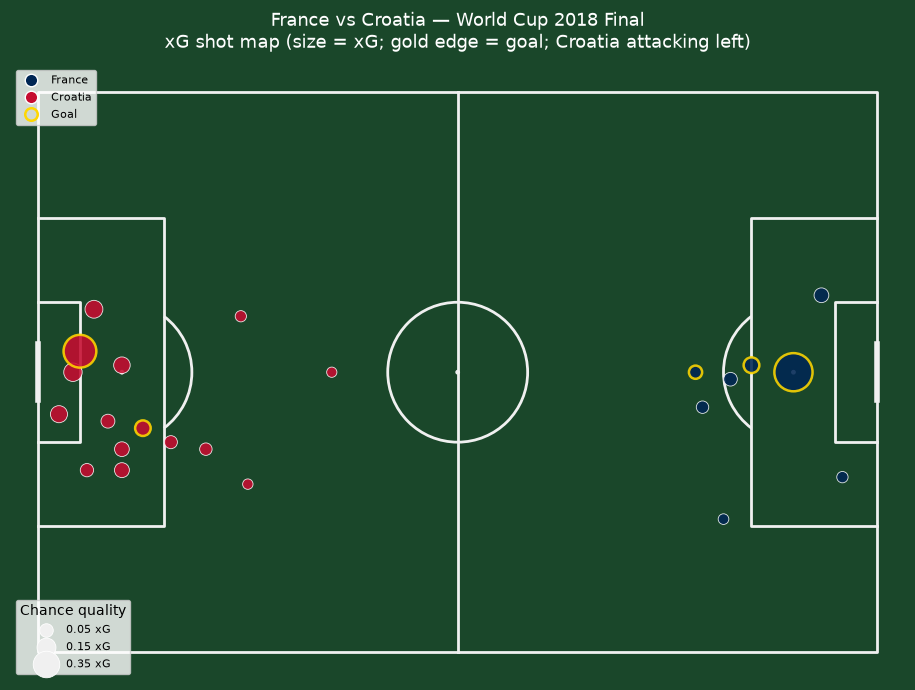

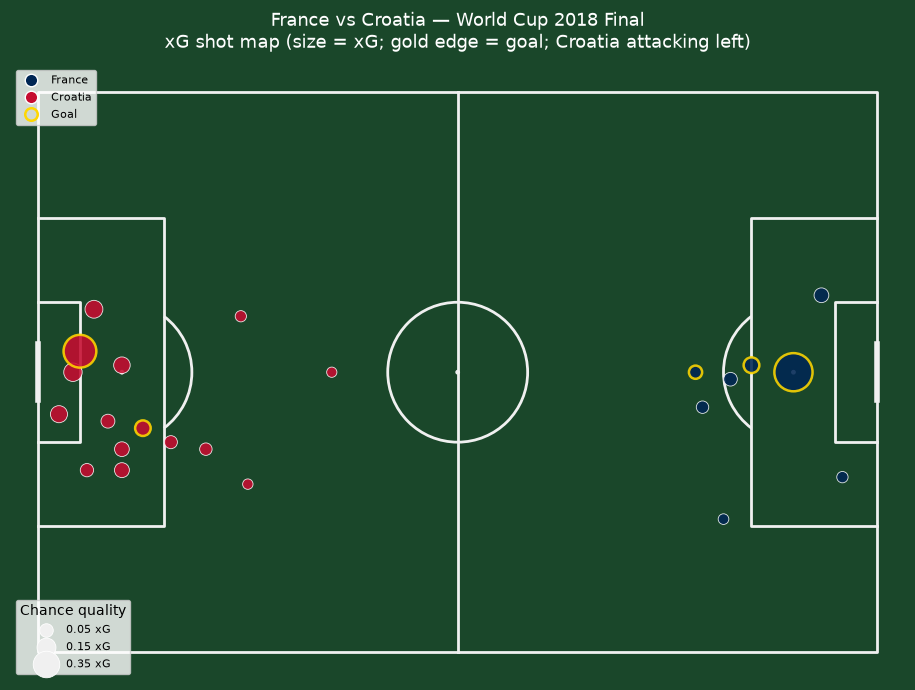

In [3]:
path_18 = OUTPUTS / f"wc2018_final_{wc18.match_id}_xg_shots.png"
fig_18 = get_xg_shot_map(
    wc18,
    title=f"{wc18.home_team} vs {wc18.away_team} — World Cup 2018 Final\nxG shot map (size = xG; gold edge = goal; {wc18.away_team} attacking left)",
    save_path=path_18,
)
print(f"Saved {path_18}")
fig_18

## 2022 — Argentina vs France

Shootout penalties are excluded, so this is extra-time 3–3, not the 4–2 result on penalties. Argentina's xG includes the in-game penalty.

Saved ..\outputs\wc2022_final_3869685_xg_shots.png


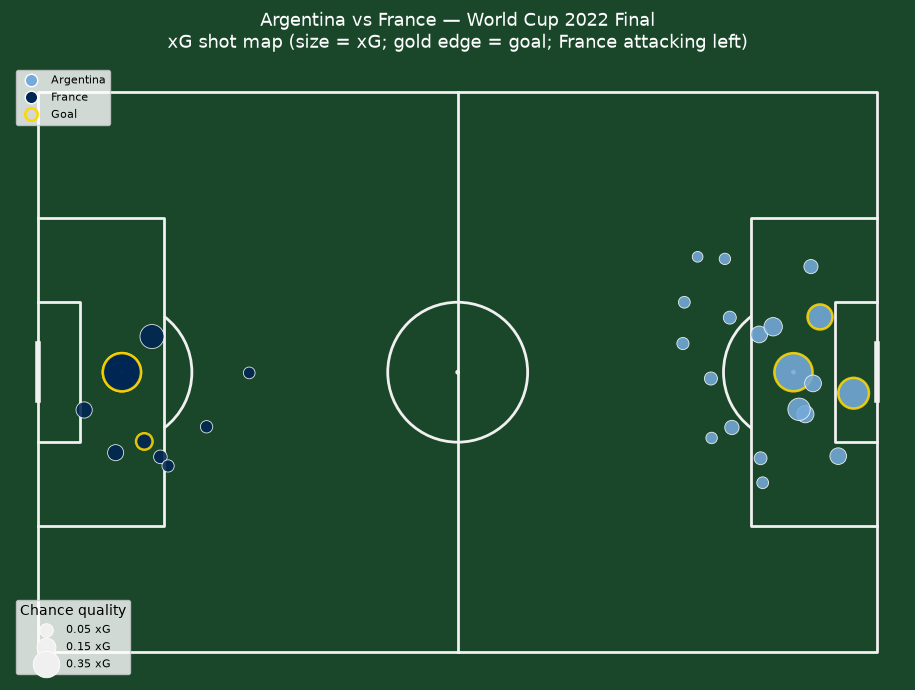

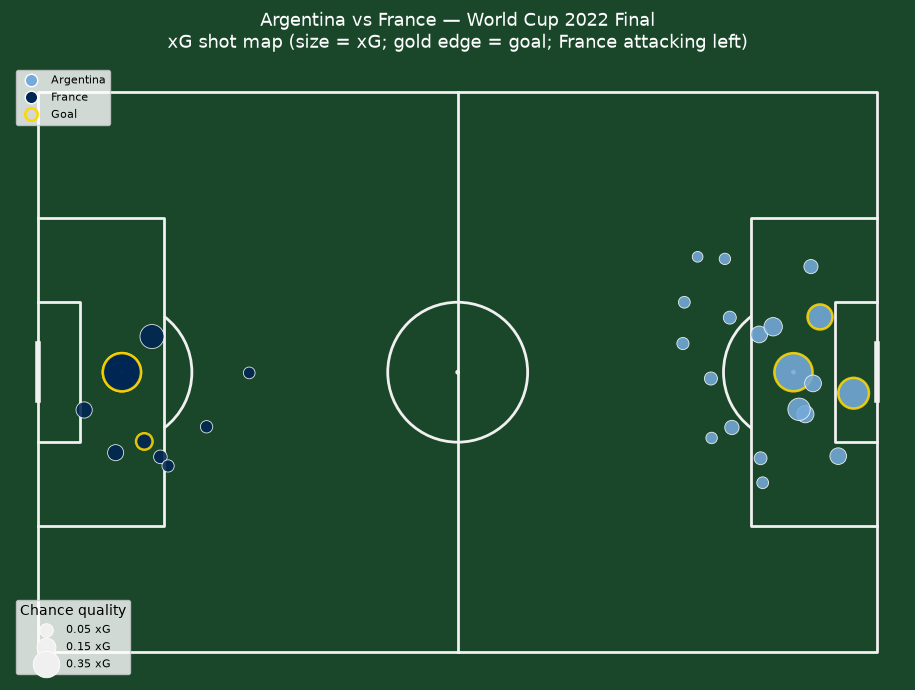

In [4]:
path_22 = OUTPUTS / f"wc2022_final_{wc22.match_id}_xg_shots.png"
fig_22 = get_xg_shot_map(
    wc22,
    title=f"{wc22.home_team} vs {wc22.away_team} — World Cup 2022 Final\nxG shot map (size = xG; gold edge = goal; {wc22.away_team} attacking left)",
    save_path=path_22,
)
print(f"Saved {path_22}")
fig_22